# Model-Agnostic EAP-IG Circuit Inspection

This notebook takes a list of model specs, checks which diagnostic and EAP-IG artifacts exist, resolves the most recent date when none is specified, and then inspects the best available circuit per model.

Assumptions used here:
- diagnostic and EAP dates are resolved independently when `date` is omitted
- the chosen circuit is the best run on the latest available EAP day for that model, ranked by best `faithfulness_mean`, then `accuracy_mean`, then smaller induced node count


In [6]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

EXECUTABLE_DIR_CANDIDATES = [
    Path.cwd() / 'scripts' / 'executable',
    Path.cwd() / 'animacy-circuit' / 'scripts' / 'executable',
    Path.cwd().parent / 'executable',
]
for executable_dir in EXECUTABLE_DIR_CANDIDATES:
    if (executable_dir / 'utils.py').exists():
        sys.path.insert(0, str(executable_dir))
        break
else:
    raise FileNotFoundError('Could not locate scripts/executable/utils.py')

import utils as inspection_utils
inspection_utils = importlib.reload(inspection_utils)

build_live_budgeted_circuit_figures = inspection_utils.build_live_budgeted_circuit_figures
build_model_reports = inspection_utils.build_model_reports
budget_curve_frame = inspection_utils.budget_curve_frame
budgeted_circuit_view = inspection_utils.budgeted_circuit_view
circuit_summary_frame = inspection_utils.circuit_summary_frame
diagnostic_summary_frame = inspection_utils.diagnostic_summary_frame
find_project_root = inspection_utils.find_project_root

pd.set_option('display.max_colwidth', 160)
pd.set_option('display.precision', 4)

In [7]:
MODEL_SPECS = [
    {'model': 'gpt2', 'date': '2026-05-30', 'run_type': 'full_model', 'dataset_set': 'model_specific_correct'},
    {'model': 'Llama 3.2 3B', 'date': '2026-05-31', 'run_type': 'full_model', 'dataset_set': 'model_specific_correct'},
    {'model': 'Gemma 3 4b pt', 'date': '2026-06-03', 'run_type': 'full_model', 'dataset_set': 'model_specific_correct'},
    {'model': 'Qwen 3 4b', 'date': '2026-06-04', 'run_type': 'full_model', 'dataset_set': 'model_specific_correct'},
]

# To inspect another run, change the date/dataset_set explicitly. This avoids accidentally
# loading shared-correct or shadow-rediscovery artifacts when newer runs exist.


In [8]:
PROJECT_ROOT = find_project_root()
availability_df, reports = build_model_reports(PROJECT_ROOT, MODEL_SPECS)

def resolve_budget_for_target_faithfulness(target, report):
    artifact = report.get('circuit_artifact')
    if artifact is None:
        return None

    budget_frame = artifact.get('budget', pd.DataFrame()).copy()
    if budget_frame is None or budget_frame.empty:
        return None

    budget_frame['faithfulness_mean'] = pd.to_numeric(budget_frame['faithfulness_mean'], errors='coerce')
    budget_frame['collapsed_edge_budget'] = pd.to_numeric(budget_frame['collapsed_edge_budget'], errors='coerce')
    budget_frame = budget_frame.dropna(subset=['faithfulness_mean', 'collapsed_edge_budget'])
    if budget_frame.empty:
        return None

    reached = budget_frame.loc[
        budget_frame['faithfulness_mean'] >= float(target)
    ].sort_values(['collapsed_edge_budget', 'faithfulness_mean'], ascending=[True, False])
    if not reached.empty:
        return int(reached.iloc[0]['collapsed_edge_budget'])

    best_budget = artifact.get('best_budget')
    if best_budget is not None and pd.notna(best_budget.get('collapsed_edge_budget')):
        return int(best_budget['collapsed_edge_budget'])

    fallback = budget_frame.sort_values(['faithfulness_mean', 'collapsed_edge_budget'], ascending=[False, True])
    return int(fallback.iloc[0]['collapsed_edge_budget'])

def resolve_circuit_budget(config, report):
    if isinstance(config, dict):
        selected = None
        for key in (report.get('display_model'), report.get('model_query')):
            if key is not None and key in config:
                selected = config[key]
                break
        if selected is None and 'target_faithfulness' in config:
            selected = {'target_faithfulness': config['target_faithfulness']}
        if isinstance(selected, dict) and 'target_faithfulness' in selected:
            return resolve_budget_for_target_faithfulness(selected['target_faithfulness'], report)
        if isinstance(selected, float) and 0.0 < selected <= 1.0:
            return resolve_budget_for_target_faithfulness(selected, report)
        return selected
    if isinstance(config, float) and 0.0 < config <= 1.0:
        return resolve_budget_for_target_faithfulness(config, report)
    return config

def make_budget_reference_frame(report):
    artifact = report.get('circuit_artifact')
    if artifact is None:
        return pd.DataFrame()

    total_components = len(artifact.get('nodes', pd.DataFrame()))
    budget_frame = artifact.get('budget', pd.DataFrame()).copy()
    if budget_frame is None or budget_frame.empty:
        return pd.DataFrame()

    budget_frame['induced_node_count'] = pd.to_numeric(budget_frame['induced_node_count'], errors='coerce')
    budget_frame['nearest_sweep_budget'] = pd.to_numeric(budget_frame['collapsed_edge_budget'], errors='coerce')
    if 'budget_fraction' in budget_frame.columns:
        budget_frame['nearest_sweep_pct'] = 100.0 * pd.to_numeric(budget_frame['budget_fraction'], errors='coerce')
    else:
        max_budget = budget_frame['nearest_sweep_budget'].max()
        budget_frame['nearest_sweep_pct'] = 100.0 * budget_frame['nearest_sweep_budget'] / max_budget if max_budget else 0.0
    budget_frame['nearest_component_count'] = budget_frame['induced_node_count'].clip(lower=0)
    budget_frame['nearest_component_pct'] = (
        100.0 * budget_frame['nearest_component_count'] / total_components
        if total_components
        else 0.0
    )

    keep_columns = [
        'nearest_sweep_pct',
        'nearest_sweep_budget',
        'nearest_component_pct',
        'nearest_component_count',
        'faithfulness_mean',
        'accuracy_mean',
    ]
    frame = budget_frame.loc[:, [column for column in keep_columns if column in budget_frame.columns]].copy()
    return frame.sort_values('nearest_sweep_pct').reset_index(drop=True)

print(f'Project root: {PROJECT_ROOT}')
display(availability_df)


Project root: /gpfs/home4/spunzo/grammatical-circuits/animacy-circuit


,model_query,display_model,requested_date,diagnostic_available,diagnostic_day,circuit_available,circuit_day,circuit_run_type,visualization_count,best_budget,best_budget_percent,best_faithfulness,best_accuracy,best_induced_node_count
0,gpt2,gpt2,2026-05-30,False,None,True,2026-05-30,full_model,5,2000,17.2250,1.0022,0.9742,123
1,Llama 3.2 3B,Llama 3.2 3B,2026-05-31,False,None,True,2026-05-31,full_model,10,16806,7.0518,0.9209,0.9809,508
2,Gemma 3 4b pt,google/gemma-3-4b-pt,2026-06-03,False,None,True,2026-06-03,full_model,5,4992,10.7758,0.8791,0.9726,156
3,Qwen 3 4b,Qwen/Qwen3-4B,2026-06-04,False,None,True,2026-06-04,full_model,5,12017,1.7426,0.8555,0.9761,668


## Diagnostic Recap

This prints the performance on the GPT-2-filtered pool first, then a minimal recap of target-model token mismatches, post-scoring metric failures, sentence-pair alignment issues, and target-set exclusions.


In [9]:
diagnostic_df = diagnostic_summary_frame(reports)
if diagnostic_df.empty:
    print('No model_diagnostic summaries found for the requested models.')
else:
    display(diagnostic_df)

for report in reports:
    display(Markdown(f"### {report['display_model']}"))
    print(report['diagnostic_recap'])


No model_diagnostic summaries found for the requested models.


### gpt2

No diagnostic summary available.


### Llama 3.2 3B

No diagnostic summary available.


### google/gemma-3-4b-pt

No diagnostic summary available.


### Qwen/Qwen3-4B

No diagnostic summary available.


## Best Circuit And Budget Curves

The summary table reports the chosen run per model and the best budget point inside that run. The plot marks that best point on top of the full budget sweep. The reference tables below list the actual evaluated sweep budgets with their percentages, faithfulness, and accuracy so you can choose `K` after looking at the curves.


,display_model,run_type,day,n_edges,n_nodes,visualization_count,best_budget,best_budget_percent,best_faithfulness,best_accuracy,best_induced_node_count,validation_examples
0,gpt2,full_model,2026-05-30,11611,156,5,2000,17.2250,1.0022,0.9742,123,4221
1,Llama 3.2 3B,full_model,2026-05-31,238323,700,10,16806,7.0518,0.9209,0.9809,508,4234
2,google/gemma-3-4b-pt,full_model,2026-06-03,46326,306,5,4992,10.7758,0.8791,0.9726,156,3871
3,Qwen/Qwen3-4B,full_model,2026-06-04,689599,1188,5,12017,1.7426,0.8555,0.9761,668,3800


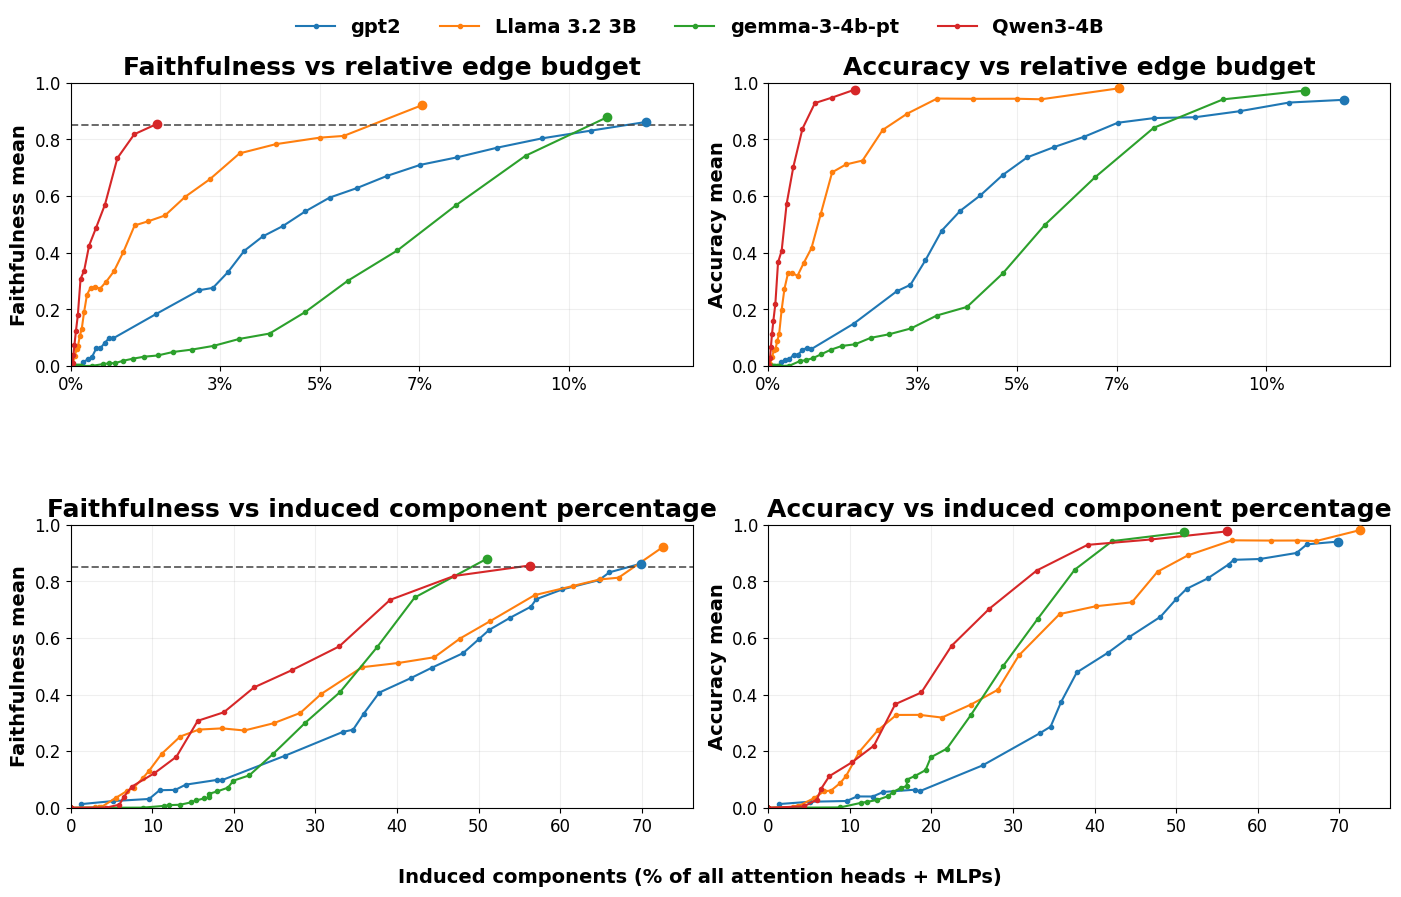

### gpt2 budget reference

,nearest_sweep_pct,nearest_sweep_budget,nearest_component_pct,nearest_component_count,faithfulness_mean,accuracy_mean
0,0.2584,30,1.2821,2,0.0129,0.0130
1,0.3445,40,5.1282,8,0.0236,0.0213
2,0.4306,50,9.6154,15,0.0311,0.0239
3,0.5168,60,10.8974,17,0.0620,0.0400
4,0.6029,70,12.8205,20,0.0632,0.0398
5,0.6890,80,14.1026,22,0.0817,0.0559
6,0.7751,90,17.9487,28,0.0984,0.0637
7,0.8613,100,18.5897,29,0.0981,0.0588
8,1.7225,200,26.2821,41,0.1840,0.1497
9,2.5838,300,33.3333,52,0.2676,0.2639


### Llama 3.2 3B budget reference

,nearest_sweep_pct,nearest_sweep_budget,nearest_component_pct,nearest_component_count,faithfulness_mean,accuracy_mean
0,0.0126,30,0.0000,0,-1.3099e-07,0.0000
1,0.0168,40,0.0000,0,-1.3099e-07,0.0000
2,0.0210,50,0.0000,0,-1.3099e-07,0.0000
3,0.0252,60,0.0000,0,-1.3099e-07,0.0000
4,0.0294,70,0.0000,0,-1.3099e-07,0.0000
5,0.0336,80,3.0000,21,1.6015e-03,0.0031
6,0.0378,90,3.4286,24,1.2663e-03,0.0031
7,0.0420,100,3.7143,26,1.7288e-03,0.0061
8,0.0839,200,5.5714,39,3.5645e-02,0.0333
9,0.1259,300,6.8571,48,5.8580e-02,0.0581


### google/gemma-3-4b-pt budget reference

,nearest_sweep_pct,nearest_sweep_budget,nearest_component_pct,nearest_component_count,faithfulness_mean,accuracy_mean
0,0.0648,30,0.0000,0,-2.5121e-07,0.0000
1,0.0863,40,0.0000,0,-2.5121e-07,0.0000
2,0.1079,50,0.0000,0,-2.5121e-07,0.0000
3,0.1295,60,0.0000,0,-2.5121e-07,0.0000
4,0.1511,70,0.0000,0,-2.5121e-07,0.0000
5,0.1727,80,0.0000,0,-2.5121e-07,0.0000
6,0.1943,90,0.0000,0,-2.5121e-07,0.0000
7,0.2159,100,0.0000,0,-2.5121e-07,0.0000
8,0.4317,200,8.8235,27,5.2333e-04,0.0013
9,0.6476,300,11.4379,35,6.5990e-03,0.0178


### Qwen/Qwen3-4B budget reference

,nearest_sweep_pct,nearest_sweep_budget,nearest_component_pct,nearest_component_count,faithfulness_mean,accuracy_mean
0,0.0044,30,0.0000,0,2.8252e-07,0.0000
1,0.0058,40,0.0000,0,2.8252e-07,0.0000
2,0.0073,50,0.0000,0,2.8252e-07,0.0000
3,0.0087,60,0.0000,0,2.8252e-07,0.0000
4,0.0102,70,0.0000,0,2.8252e-07,0.0000
5,0.0116,80,0.0000,0,2.8252e-07,0.0000
6,0.0131,90,0.0000,0,2.8252e-07,0.0000
7,0.0145,100,0.0000,0,2.8252e-07,0.0000
8,0.0290,200,4.3771,52,5.8774e-04,0.0050
9,0.0435,300,5.9764,71,1.1051e-02,0.0287


In [10]:
circuit_df = circuit_summary_frame(reports)
if circuit_df.empty:
    print('No EAP-IG circuit runs found for the requested models.')
else:
    display(circuit_df)

budget_df = budget_curve_frame(reports)
if budget_df.empty:
    print('No budget sweep CSVs available for the chosen runs.')
else:
    numeric_columns = [
        'collapsed_edge_budget',
        'budget_fraction',
        'faithfulness_mean',
        'faithfulness_std',
        'accuracy_mean',
        'accuracy_std',
        'expanded_edge_count',
        'induced_node_count',
        'validation_examples',
    ]
    for column in numeric_columns:
        if column in budget_df.columns:
            budget_df[column] = pd.to_numeric(budget_df[column], errors='coerce')

    def clean_budget_curve_label(report):
        label = str(report['display_model'])
        if '/' in label:
            label = label.split('/')[-1]
        return label

    title_size = 18
    label_size = 14
    tick_size = 12
    legend_size = 14
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    plotted_budget_fractions = []
    for report in reports:
        artifact = report.get('circuit_artifact')
        if artifact is None or artifact['budget'].empty:
            continue

        sub = artifact['budget'].copy()
        for column in numeric_columns:
            if column in sub.columns:
                sub[column] = pd.to_numeric(sub[column], errors='coerce')
        if 'budget_fraction' not in sub.columns:
            max_budget = sub['collapsed_edge_budget'].max()
            sub['budget_fraction'] = sub['collapsed_edge_budget'] / max_budget if max_budget else 0.0
        total_components = len(artifact.get('nodes', pd.DataFrame()))
        sub['induced_node_count_clipped'] = sub['induced_node_count'].clip(lower=0)
        sub['component_fraction'] = (
            sub['induced_node_count_clipped'] / total_components if total_components else 0.0
        )
        sub['component_percent'] = 100.0 * sub['component_fraction']
        sub = sub.sort_values('budget_fraction')
        label = clean_budget_curve_label(report)
        plot_best_budget = best_budget = artifact.get('best_budget')
        if label == 'gpt2':
            reached = sub.loc[sub['faithfulness_mean'] >= 0.85].sort_values('budget_fraction')
            if not reached.empty:
                gpt2_budget_cap = float(reached.iloc[0]['budget_fraction'])
                sub = sub.loc[sub['budget_fraction'] <= gpt2_budget_cap].copy()
                plot_best_budget = reached.iloc[0]
        if not sub.empty:
            plotted_budget_fractions.extend(sub['budget_fraction'].tolist())

        axes[0, 0].plot(sub['budget_fraction'], sub['faithfulness_mean'], marker='o', markersize=3, label=label)
        axes[0, 1].plot(sub['budget_fraction'], sub['accuracy_mean'], marker='o', markersize=3, label=label)
        axes[1, 0].plot(sub['component_percent'], sub['faithfulness_mean'], marker='o', markersize=3, label=label)
        axes[1, 1].plot(sub['component_percent'], sub['accuracy_mean'], marker='o', markersize=3, label=label)

        if plot_best_budget is not None:
            best_x = plot_best_budget.get('budget_fraction')
            if best_x is None:
                max_budget = sub['collapsed_edge_budget'].max()
                best_x = plot_best_budget['collapsed_edge_budget'] / max_budget if max_budget else 0.0
            best_component_x = (
                100.0 * max(float(plot_best_budget.get('induced_node_count', 0.0)), 0.0) / total_components
                if total_components
                else 0.0
            )
            axes[0, 0].scatter(
                [best_x],
                [plot_best_budget['faithfulness_mean']],
                s=36,
                zorder=3,
            )
            axes[0, 1].scatter(
                [best_x],
                [plot_best_budget['accuracy_mean']],
                s=36,
                zorder=3,
            )
            axes[1, 0].scatter(
                [best_component_x],
                [plot_best_budget['faithfulness_mean']],
                s=36,
                zorder=3,
            )
            axes[1, 1].scatter(
                [best_component_x],
                [plot_best_budget['accuracy_mean']],
                s=36,
                zorder=3,
            )

    axes[0, 0].axhline(0.85, color='#444444', linestyle='--', linewidth=1.4, alpha=0.8)
    axes[1, 0].axhline(0.85, color='#444444', linestyle='--', linewidth=1.4, alpha=0.8)
    axes[0, 0].set_title('Faithfulness vs relative edge budget', fontsize=title_size, fontweight='bold')
    axes[0, 1].set_title('Accuracy vs relative edge budget', fontsize=title_size, fontweight='bold')
    axes[1, 0].set_title('Faithfulness vs induced component percentage', fontsize=title_size, fontweight='bold')
    axes[1, 1].set_title('Accuracy vs induced component percentage', fontsize=title_size, fontweight='bold')
    axes[0, 0].set_ylabel('Faithfulness mean', fontsize=label_size, fontweight='bold')
    axes[1, 0].set_ylabel('Faithfulness mean', fontsize=label_size, fontweight='bold')
    axes[0, 1].set_ylabel('Accuracy mean', fontsize=label_size, fontweight='bold')
    axes[1, 1].set_ylabel('Accuracy mean', fontsize=label_size, fontweight='bold')
    positive_budget_fractions = [value for value in plotted_budget_fractions if value > 0]
    min_budget_fraction = float(min(positive_budget_fractions)) if positive_budget_fractions else 1e-4
    max_budget_fraction = float(max(plotted_budget_fractions)) if plotted_budget_fractions else 0.0
    axis_right = max_budget_fraction * 1.08 if max_budget_fraction > 0 else 0.0
    tick_vals = [min_budget_fraction, 0.03, 0.05, 0.07, 0.10, 0.13, 0.15]
    tick_labels = ['0%', '3%', '5%', '7%', '10%', '13%', '15%']
    tick_pairs = [
        (value, label)
        for value, label in zip(tick_vals, tick_labels)
        if min_budget_fraction <= value <= axis_right
    ]
    if not tick_pairs:
        tick_pairs = [(min_budget_fraction, '0%')]
    tick_vals = [value for value, _ in tick_pairs]
    tick_labels = [label for _, label in tick_pairs]
    for ax in axes[0]:
        ax.set_xscale('linear')
        ax.set_xticks(tick_vals)
        ax.set_xticklabels(tick_labels, fontsize=tick_size)
        ax.set_xlim(min_budget_fraction, axis_right)
        ax.tick_params(axis='y', labelsize=tick_size)
        ax.set_ylim(0.0, 1.0)
        ax.grid(alpha=0.2)
    for ax in axes[1]:
        ax.set_xlim(left=0)
        ax.tick_params(axis='both', labelsize=tick_size)
        ax.set_ylim(0.0, 1.0)
        ax.grid(alpha=0.2)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.995), ncol=max(1, len(labels)), frameon=False, prop={'size': legend_size, 'weight': 'bold'})
    plt.tight_layout(rect=[0.03, 0.05, 0.97, 0.95])
    fig.subplots_adjust(hspace=0.56)
    # fig.text(0.5, 0.515, 'Collapsed edge budget (% of ranked model edges)', ha='center', va='center', fontsize=label_size, fontweight='bold')
    fig.text(0.5, 0.02, 'Induced components (% of all attention heads + MLPs)', ha='center', va='center', fontsize=label_size, fontweight='bold')
    plt.show()

for report in reports:
    display(Markdown(f"### {report['display_model']} budget reference"))
    reference_df = make_budget_reference_frame(report)
    report['budget_reference'] = reference_df
    if reference_df.empty:
        print('No ranked edge artifact available for this model.')
        continue
    display(reference_df)


In [11]:
for report in reports:
    reference_df = make_budget_reference_frame(report)
    report['budget_reference'] = reference_df
    print(report['display_model'])
    print(report['budget_reference']['nearest_sweep_budget'].values)

gpt2
[  30   40   50   60   70   80   90  100  200  300  332  367  405  448
  495  547  604  667  737  815  900  995 1099 1214 1342 1483 1638 1810
 2000]
Llama 3.2 3B
[   30    40    50    60    70    80    90   100   200   300   365   443
   537   652   791   960  1165  1414  1717  2084  2529  3070  3726  4523
  5490  6664  8089  9818 11917 13068 16806]
google/gemma-3-4b-pt
[  30   40   50   60   70   80   90  100  200  300  354  418  493  582
  686  810  955 1127 1330 1569 1851 2184 2576 3040 3586 4231 4992]
Qwen/Qwen3-4B
[   30    40    50    60    70    80    90   100   200   300   409   555
   755  1027  1397  1899  2583  3513  4777  6497  8836 12017]


## Budget Selection And Visualizations

Set `CIRCUIT_BUDGET` in the next cell after inspecting the budget curves and reference tables above. The figures below are rebuilt live from the saved ranked edges for each model's selected budget. No saved HTML or PNG visualizations are used here.


In [12]:
# Set this after inspecting the budget curves above.
# CIRCUIT_BUDGET can be:
# - None: use each run's best evaluated budget
# - an int: use the same budget for every model
# - a float in (0, 1]: choose the smallest evaluated budget that reaches that faithfulness
# - a dict keyed by display model or model query: use model-specific budgets or target_faithfulness configs
CIRCUIT_BUDGET = 0.85
TOP_EDGE_ROWS = 100
TOP_COMPONENT_ROWS = 100
LIVE_TOP_K_EDGES = 100
LAYERED_CIRCUIT_MIN_HEIGHT = 45
LAYERED_CIRCUIT_HEIGHT_PER_NODE = 12

for report in reports:
    artifact = report.get('circuit_artifact')
    requested_budget = resolve_circuit_budget(CIRCUIT_BUDGET, report)
    report['requested_circuit_budget'] = requested_budget
    if artifact is None:
        report['budgeted_circuit'] = None
        continue
    try:
        report['budgeted_circuit'] = budgeted_circuit_view(
            artifact,
            budget=requested_budget,
            top_edge_rows=TOP_EDGE_ROWS,
            top_component_rows=TOP_COMPONENT_ROWS,
        )
    except ValueError as exc:
        raise ValueError(f"{report['display_model']}: {exc}") from exc

for report in reports:
    budgeted = report.get('budgeted_circuit')
    requested_budget = report.get('requested_circuit_budget')
    display(Markdown(f"### {report['display_model']}"))
    if budgeted is None:
        print('No circuit artifacts available.')
        continue

    selected_budget = budgeted['collapsed_edge_budget']
    budget_origin = 'best evaluated budget' if requested_budget is None else f'requested budget={requested_budget}'
    evaluated_note = 'evaluated in the saved sweep' if budgeted['is_evaluated_budget'] else 'not directly evaluated in the saved sweep'
    display(Markdown(
        f"Top-{selected_budget} collapsed-edge circuit ({budget_origin}; max available: {budgeted['max_budget']}; {evaluated_note})."
    ))

    selected_budget_row = budgeted.get('evaluated_budget_row')
    if selected_budget_row is not None:
        display(pd.DataFrame([selected_budget_row]))

    figures = build_live_budgeted_circuit_figures(
        budgeted['edges'],
        budgeted['nodes'],
        top_k_edges=min(LIVE_TOP_K_EDGES, selected_budget),
        layered_circuit_min_height=LAYERED_CIRCUIT_MIN_HEIGHT,
        layered_circuit_height_per_node=LAYERED_CIRCUIT_HEIGHT_PER_NODE,
    )

    display(Markdown('**Layered circuit**'))
    display(figures['layered_circuit'])

    display(Markdown('**Residualized full circuit (path-length normalized routed load)**'))
    display(figures['residualized_normalized'])

    display(Markdown('**Layer-to-layer heatmap**'))
    display(figures['layer_flow'])

    display(Markdown('**Induced score heatmap for heads and MLPs**'))
    display(figures['component_score_heatmap'])


### gpt2

Top-1342 collapsed-edge circuit (requested budget=1342; max available: 11611; evaluated in the saved sweep).

,collapsed_edge_budget,budget_fraction,expanded_edge_count,induced_node_count,faithfulness_mean,faithfulness_std,accuracy_mean,accuracy_std,validation_examples
24,1342.0,0.1156,3111.0,109.0,0.8621,0.2359,0.9401,0.2374,4221.0


**Layered circuit**

**Residualized full circuit (path-length normalized routed load)**

...

,collapsed_edge_budget,budget_fraction,expanded_edge_count,induced_node_count,faithfulness_mean,faithfulness_std,accuracy_mean,accuracy_std,validation_examples
21,12017.0,0.0174,27433.0,668.0,0.8555,4.9875,0.9761,0.1529,3800.0


**Layered circuit**

**Residualized full circuit (path-length normalized routed load)**

**Layer-to-layer heatmap**

**Induced score heatmap for heads and MLPs**

## Combined Induced-Score Heatmaps

Run this cell after the circuit figures cell above. It renders a static 2x2 Matplotlib figure with one colorbar per model, so you can retune layout without rerunning the earlier notebook sections.


NameError: name 'suptitle' is not defined

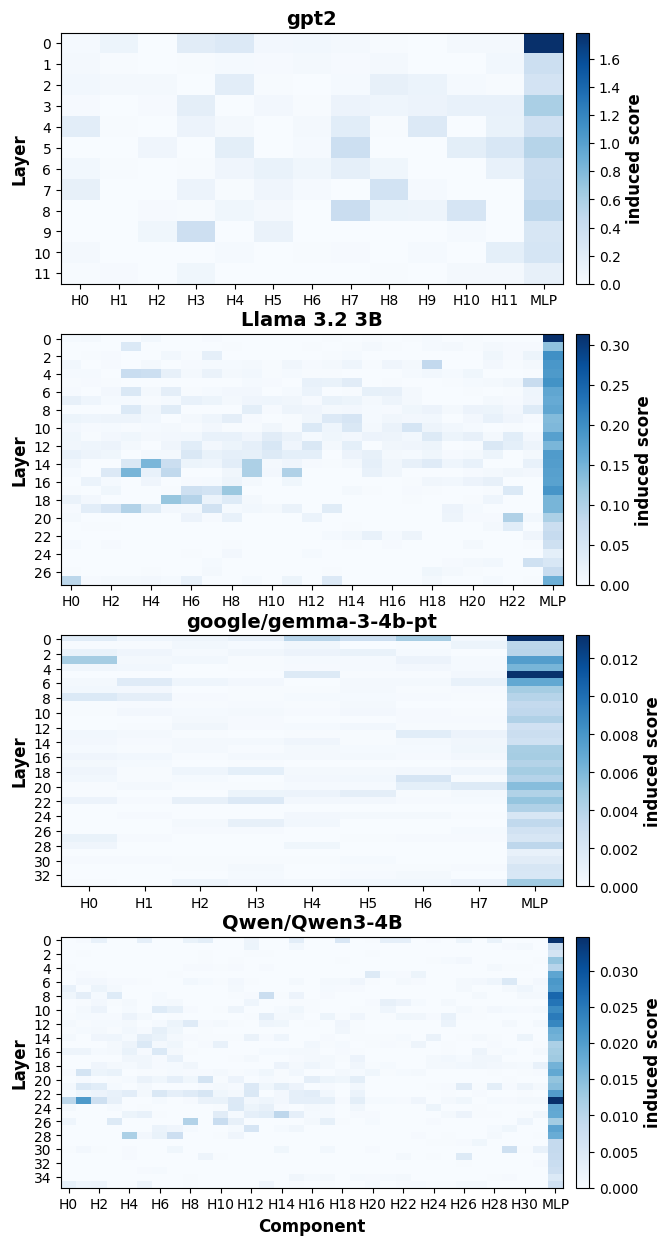

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def incident_edge_counts(edges):
    if edges is None or edges.empty:
        return {}
    incident_nodes = pd.concat([edges['parent'], edges['child']], ignore_index=True)
    return incident_nodes.astype(str).value_counts().to_dict()


def collect_component_heatmap_panels(reports):
    heatmap_panels = []
    for report in reports:
        budgeted = report.get('budgeted_circuit')
        if budgeted is None:
            continue
        figures = build_live_budgeted_circuit_figures(
            budgeted['edges'],
            budgeted['nodes'],
            top_k_edges=min(LIVE_TOP_K_EDGES, budgeted['collapsed_edge_budget']),
            layered_circuit_min_height=LAYERED_CIRCUIT_MIN_HEIGHT,
            layered_circuit_height_per_node=LAYERED_CIRCUIT_HEIGHT_PER_NODE,
        )
        heatmap_fig = figures.get('component_score_heatmap')
        if heatmap_fig is None or not heatmap_fig.data:
            continue
        trace = heatmap_fig.data[0]
        raw_z = np.asarray(trace.z, dtype=float)
        normalized_z = np.zeros_like(raw_z, dtype=float)
        counts = incident_edge_counts(budgeted['edges'])
        customdata = np.asarray(trace.customdata, dtype=object)
        for row_idx in range(raw_z.shape[0]):
            for col_idx in range(raw_z.shape[1]):
                cell = customdata[row_idx, col_idx] if customdata.shape == raw_z.shape else None
                node = cell.get('node') if isinstance(cell, dict) else None
                incident_count = counts.get(str(node), 0) if node is not None else 0
                normalized_z[row_idx, col_idx] = raw_z[row_idx, col_idx] / incident_count if incident_count else 0.0
        heatmap_panels.append({
            'title': report['display_model'],
            'z': raw_z,
            'normalized_z': normalized_z,
            'x': [label[1:] if isinstance(label, str) and label.startswith('L') else label for label in trace.x],
            'y': list(trace.y),
        })
    return heatmap_panels


def plot_combined_component_heatmaps_static(
    heatmap_panels,
    *,
    fig_width=13.5,
    fig_height=11.0,
    top_row_height_ratio=1.0,
    bottom_row_height_ratio=1.18,
    wspace=0.32,
    hspace=0.3,
    top=0.9,
    colorbar_fraction=0.05,
    colorbar_pad=0.025,
    x_tick_fontsize=10,
    y_tick_fontsize=10,
    axis_label_fontsize=12,
    colorbar_label_fontsize=12,
    title_fontsize=13,
    suptitle_fontsize=18,
    suptitle_y=0.94,
    x_tick_rotation=0,
    value_key='z',
    colorbar_label='induced score',
    suptitle='Induced score heatmaps across circuits',
):
    if len(heatmap_panels) != 4:
        raise ValueError(f'Expected 4 heatmap panels, got {len(heatmap_panels)}.')

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(fig_width, fig_height),
        constrained_layout=False,
        gridspec_kw={'height_ratios': [top_row_height_ratio, top_row_height_ratio, top_row_height_ratio, bottom_row_height_ratio]},
    )
    axes = np.atleast_1d(axes).flatten()

    for panel_index, (ax, panel) in enumerate(zip(axes, heatmap_panels), start=1):
        values = np.asarray(panel[value_key], dtype=float).T
        masked_values = np.ma.masked_invalid(values)
        valid_values = values[np.isfinite(values)]
        vmax = float(valid_values.max()) if valid_values.size else 1.0
        if vmax <= 0:
            vmax = 1.0

        image = ax.imshow(
            masked_values,
            cmap='Blues',
            aspect='auto',
            interpolation='nearest',
            vmin=0.0,
            vmax=vmax,
            origin='upper',
        )
        ax.set_title(panel['title'], fontsize=title_fontsize, fontweight='bold')
        row_index = panel_index - 1
        is_llama_panel = 'llama' in panel['title'].lower()
        x_tick_positions = np.arange(len(panel['y']))
        x_tick_labels = panel['y']
        if is_llama_panel or row_index == len(heatmap_panels) - 1:
            x_tick_positions = np.arange(0, len(panel['y']), 2)
            x_tick_labels = [panel['y'][tick_index] for tick_index in x_tick_positions]
        y_tick_positions = np.arange(len(panel['x']))
        y_tick_labels = panel['x']
        if is_llama_panel or row_index >= len(heatmap_panels) - 2:
            y_tick_positions = np.arange(0, len(panel['x']), 2)
            y_tick_labels = [panel['x'][tick_index] for tick_index in y_tick_positions]

        ax.set_xticks(x_tick_positions)
        ax.set_xticklabels(x_tick_labels, rotation=x_tick_rotation, fontsize=x_tick_fontsize)
        ax.set_yticks(y_tick_positions)
        ax.set_yticklabels(y_tick_labels, fontsize=y_tick_fontsize)

        if row_index == len(heatmap_panels) - 1:
            ax.set_xlabel('Component', fontsize=axis_label_fontsize, fontweight='bold')
        ax.set_ylabel('Layer', fontsize=axis_label_fontsize, fontweight='bold')

        colorbar = fig.colorbar(image, ax=ax, fraction=colorbar_fraction, pad=colorbar_pad)
        colorbar.set_label(colorbar_label, fontsize=colorbar_label_fontsize, fontweight='bold')

    fig.suptitle(suptitle, fontsize=suptitle_fontsize, fontweight='bold', y=suptitle_y)
    fig.subplots_adjust(wspace=wspace, hspace=hspace, top=top)
    return fig


combined_component_heatmap_fig_width = 7
combined_component_heatmap_fig_height = 15
combined_component_heatmap_top_row_height_ratio = 1.0
combined_component_heatmap_bottom_row_height_ratio = 1.0
combined_component_heatmap_wspace = 0.2
combined_component_heatmap_hspace = 0.25
combined_component_heatmap_top = 0.9
combined_component_heatmap_colorbar_fraction = 0.05
combined_component_heatmap_colorbar_pad = 0.025
combined_component_heatmap_x_tick_fontsize = 10
combined_component_heatmap_y_tick_fontsize = 10
combined_component_heatmap_axis_label_fontsize = 12
combined_component_heatmap_colorbar_label_fontsize = 12
combined_component_heatmap_title_fontsize = 14
combined_component_heatmap_suptitle_fontsize = 19
combined_component_heatmap_suptitle_y = 0.935
combined_component_heatmap_x_tick_rotation = 0

combined_component_heatmap_panels = collect_component_heatmap_panels(reports)
if len(combined_component_heatmap_panels) != 4:
    raise ValueError(f'Combined heatmap expects 4 model panels, found {len(combined_component_heatmap_panels)}.')

plot_combined_component_heatmaps_static(
    combined_component_heatmap_panels,
    fig_width=combined_component_heatmap_fig_width,
    fig_height=combined_component_heatmap_fig_height,
    top_row_height_ratio=combined_component_heatmap_top_row_height_ratio,
    bottom_row_height_ratio=combined_component_heatmap_bottom_row_height_ratio,
    wspace=combined_component_heatmap_wspace,
    hspace=combined_component_heatmap_hspace,
    top=combined_component_heatmap_top,
    colorbar_fraction=combined_component_heatmap_colorbar_fraction,
    colorbar_pad=combined_component_heatmap_colorbar_pad,
    x_tick_fontsize=combined_component_heatmap_x_tick_fontsize,
    y_tick_fontsize=combined_component_heatmap_y_tick_fontsize,
    axis_label_fontsize=combined_component_heatmap_axis_label_fontsize,
    colorbar_label_fontsize=combined_component_heatmap_colorbar_label_fontsize,
    title_fontsize=combined_component_heatmap_title_fontsize,
    suptitle_fontsize=combined_component_heatmap_suptitle_fontsize,
    suptitle_y=combined_component_heatmap_suptitle_y,
    x_tick_rotation=combined_component_heatmap_x_tick_rotation,
)
plt.show()

plot_combined_component_heatmaps_static(
    combined_component_heatmap_panels,
    fig_width=combined_component_heatmap_fig_width,
    fig_height=combined_component_heatmap_fig_height,
    top_row_height_ratio=combined_component_heatmap_top_row_height_ratio,
    bottom_row_height_ratio=combined_component_heatmap_bottom_row_height_ratio,
    wspace=combined_component_heatmap_wspace,
    hspace=combined_component_heatmap_hspace,
    top=combined_component_heatmap_top,
    colorbar_fraction=combined_component_heatmap_colorbar_fraction,
    colorbar_pad=combined_component_heatmap_colorbar_pad,
    x_tick_fontsize=combined_component_heatmap_x_tick_fontsize,
    y_tick_fontsize=combined_component_heatmap_y_tick_fontsize,
    axis_label_fontsize=combined_component_heatmap_axis_label_fontsize,
    colorbar_label_fontsize=combined_component_heatmap_colorbar_label_fontsize,
    title_fontsize=combined_component_heatmap_title_fontsize,
    suptitle_fontsize=combined_component_heatmap_suptitle_fontsize,
    suptitle_y=combined_component_heatmap_suptitle_y,
    x_tick_rotation=combined_component_heatmap_x_tick_rotation,
    value_key='normalized_z',
    colorbar_label='induced score / incident edge count',
    suptitle='Normalized induced score heatmaps across circuits',
)
plt.show()


## Top Edges, MLPs, And Attention Heads

These tables are recomputed from the selected top-`K` circuit. MLP and attention-head induced scores are derived from the truncated edge set shown above.


In [9]:
for report in reports:
    budgeted = report.get('budgeted_circuit')
    display(Markdown(f"### {report['display_model']}"))
    if budgeted is None:
        print('No circuit artifact available.')
        continue

    display(Markdown('**Top edges**'))
    display(budgeted['top_edges'].head(TOP_EDGE_ROWS))

    display(Markdown('**Top MLPs**'))
    display(budgeted['top_mlps'].head(TOP_COMPONENT_ROWS))

    display(Markdown('**Top attention heads**'))
    display(budgeted['top_attention_heads'].head(TOP_COMPONENT_ROWS))


### gpt2

**Top edges**

,rank,collapsed_edge,parent,child,abs_score,signed_sum,underlying_edge_count
0,1,input->m0,input,m0,0.6919,-0.6919,1
1,2,m0->m1,m0,m1,0.1454,-0.1454,1
2,3,m10->logits,m10,logits,0.1387,-0.1387,1
3,4,m9->logits,m9,logits,0.1238,-0.1238,1
4,5,a9.h3->logits,a9.h3,logits,0.1164,-0.1164,1
...,...,...,...,...,...,...,...
95,96,a4.h11->m4,a4.h11,m4,0.0132,-0.0132,1
96,97,m0->a2.h1,m0,a2.h1,0.0132,-0.0132,3
97,98,m0->a2.h0,m0,a2.h0,0.0128,0.0128,3
98,99,m2->m3,m2,m3,0.0128,0.0128,1


**Top MLPs**

,node,layer,head,induced_score,rank
0,m0,0,NaN,1.7865,1
1,m3,3,NaN,0.6016,2
2,m5,5,NaN,0.5355,3
3,m8,8,NaN,0.4896,4
4,m7,7,NaN,0.4129,5
5,m6,6,NaN,0.3937,7
6,m1,1,NaN,0.3863,8
7,m4,4,NaN,0.3517,11
8,m2,2,NaN,0.3256,13
9,m10,10,NaN,0.3056,14


...

,rank,collapsed_edge,parent,child,abs_score,signed_sum,underlying_edge_count
0,1,input->m0,input,m0,0.0044,-0.0044,1
1,2,input->a0.h18,input,a0.h18,0.0031,-0.0031,3
2,3,m28->logits,m28,logits,0.0027,-0.0027,1
3,4,m32->logits,m32,logits,0.0026,-0.0026,1
4,5,m0->m1,m0,m1,0.0023,-0.0023,1
...,...,...,...,...,...,...,...
95,96,m33->m35,m33,m35,0.0005,0.0005,1
96,97,a34.h15->logits,a34.h15,logits,0.0005,-0.0005,1
97,98,a26.h10->m27,a26.h10,m27,0.0005,-0.0005,1
98,99,m27->a30.h29,m27,a30.h29,0.0005,-0.0005,3


**Top MLPs**

,node,layer,head,induced_score,rank
0,m23,23,NaN,0.0347,1
1,m0,0,NaN,0.0344,2
2,m8,8,NaN,0.0274,3
3,m9,9,NaN,0.0256,4
4,m11,11,NaN,0.0246,5
5,m12,12,NaN,0.0232,6
6,m10,10,NaN,0.0226,7
7,m6,6,NaN,0.0207,8
8,m7,7,NaN,0.0200,10
9,m22,22,NaN,0.0198,11


**Top attention heads**

,node,layer,head,induced_score,rank
0,a23.h1,23,1.0,0.0205,9
1,a28.h4,28,4.0,0.0115,27
2,a26.h8,26,8.0,0.0108,29
3,a23.h0,23,0.0,0.0097,31
4,a25.h14,25,14.0,0.0096,32
...,...,...,...,...,...
95,a9.h22,9,22.0,0.0019,132
96,a20.h11,20,11.0,0.0019,133
97,a22.h2,22,2.0,0.0019,134
98,a10.h2,10,2.0,0.0019,135


Note: the rank is the component rank


--- Intersections for TOP EDGES ---
10 shared top edges (GPT-2 & Llama): {'input->m0', 'm2->m3', 'm1->m2', 'm0->m2', 'input->a0.h4', 'm0->m3', 'input->a0.h1', 'm0->m1', 'm5->m8', 'm3->m5'}
12 shared top edges (GPT-2 & Gemma): {'input->m0', 'm2->m3', 'a0.h4->m0', 'm6->m8', 'm0->m3', 'm0->m4', 'm8->m9', 'm6->m7', 'm0->m1', 'm3->a5.h4', 'm0->m5', 'm3->m5'}
13 shared top edges (GPT-2 & Qwen): {'input->m0', 'input->a0.h5', 'm2->m3', 'm7->m11', 'm0->m2', 'm6->m8', 'm0->m3', 'm0->m4', 'm8->m9', 'm8->m10', 'm0->m1', 'm0->m5', 'm3->m5'}
20 shared top edges (Llama & Gemma): {'input->m0', 'm0->m1', 'm25->logits', 'm20->logits', 'm26->logits', 'm0->m3', 'm23->logits', 'm16->m18', 'm27->logits', 'm22->logits', 'm19->logits', 'm3->m4', 'm21->logits', 'm15->m16', 'input->m3', 'm3->m5', 'm2->m3', 'input->m1', 'input->m2', 'm11->m15'}
11 shared top edges (Llama & Qwen): {'input->m0', 'm27->logits', 'm2->m3', 'm1->m3', 'm2->m4', 'm3->m4', 'm0->m2', 'm0->m3', 'm23->logits', 'm0->m1', 'm3->m5'}
22 shared

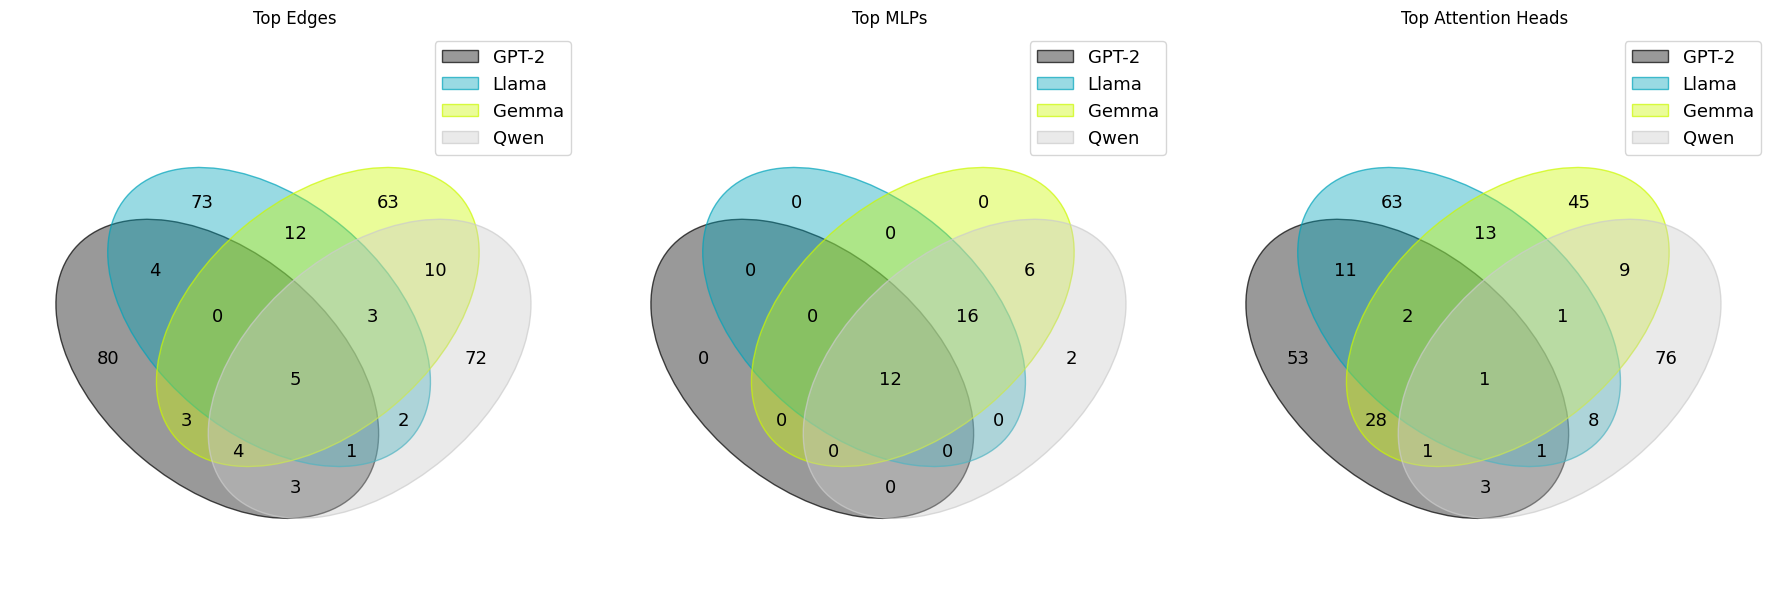

In [10]:
import itertools
import matplotlib.pyplot as plt
from venn import venn  # pip install venn


def find_report(*candidates):
    for candidate in candidates:
        report = next(
            (
                r for r in reports
                if r.get('display_model') == candidate or r.get('spec', {}).get('model') == candidate
            ),
            None,
        )
        if report is not None:
            return report
    return None


def ensure_budgeted_circuit(report):
    if report is None:
        return None
    budgeted = report.get('budgeted_circuit')
    if budgeted is not None:
        return budgeted

    artifact = report.get('circuit_artifact')
    if artifact is None:
        return None

    requested_budget = report.get('requested_circuit_budget')
    if requested_budget is None and 'CIRCUIT_BUDGET' in globals():
        requested_budget = resolve_circuit_budget(CIRCUIT_BUDGET, report)
        report['requested_circuit_budget'] = requested_budget

    budgeted = budgeted_circuit_view(
        artifact,
        budget=requested_budget,
        top_edge_rows=TOP_EDGE_ROWS,
        top_component_rows=TOP_COMPONENT_ROWS,
    )
    report['budgeted_circuit'] = budgeted
    return budgeted


gpt2_report = find_report('gpt2')
llama_report = find_report('Llama 3.2 3B', 'meta-llama/Llama-3.2-3B')
gemma_report = find_report('Gemma 3 4b pt', 'google/gemma-3-4b-pt')
qwen_report = find_report('Qwen 3 4B', 'Qwen 3 4b', 'Qwen/Qwen3-4B')

gpt2_budgeted = ensure_budgeted_circuit(gpt2_report)
llama_budgeted = ensure_budgeted_circuit(llama_report)
gemma_budgeted = ensure_budgeted_circuit(gemma_report)
qwen_budgeted = ensure_budgeted_circuit(qwen_report)

missing = [
    name
    for name, budgeted in [
        ('GPT-2', gpt2_budgeted),
        ('Llama', llama_budgeted),
        ('Gemma', gemma_budgeted),
        ('Qwen', qwen_budgeted),
    ]
    if budgeted is None
]

if missing:
    print('Missing budgeted circuits for:', ', '.join(missing))
else:
    models = {
        'GPT-2': gpt2_budgeted,
        'Llama': llama_budgeted,
        'Gemma': gemma_budgeted,
        'Qwen': qwen_budgeted,
    }

    edge_sets = {name: set(b['top_edges']['collapsed_edge']) for name, b in models.items()}
    mlp_sets = {name: set(b['top_mlps']['node']) for name, b in models.items()}
    attn_sets = {name: set(b['top_attention_heads']['node']) for name, b in models.items()}

    model_names = list(models.keys())
    categories = [
        ('top edges', edge_sets),
        ('top MLPs', mlp_sets),
        ('top attention heads', attn_sets),
    ]

    for cat_name, cat_sets in categories:
        print(f"\n--- Intersections for {cat_name.upper()} ---")
        for r in range(2, 5):
            for combo in itertools.combinations(model_names, r):
                intersection = set.intersection(*(cat_sets[m] for m in combo))
                combo_str = ' & '.join(combo)
                print(f"{len(intersection)} shared {cat_name} ({combo_str}): {intersection}")

    selected_cmap = 'nipy_spectral'

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    venn(edge_sets, ax=axes[0], cmap=selected_cmap)
    axes[0].set_title('Top Edges')
    venn(mlp_sets, ax=axes[1], cmap=selected_cmap)
    axes[1].set_title('Top MLPs')
    venn(attn_sets, ax=axes[2], cmap=selected_cmap)
    axes[2].set_title('Top Attention Heads')
    plt.tight_layout()
    plt.show()


## Shared-Correct 85% Circuit Overlap

This compares each model's `model_specific_correct` 85% faithfulness collapsed-edge circuit to the matching `shared_correct` 85% faithfulness collapsed-edge circuit.



In [11]:
SHARED_CORRECT_TARGET_FAITHFULNESS = 0.85
SHARED_CORRECT_DATASET_SET = 'shared_correct'
MODEL_SPECIFIC_DATASET_SET = 'model_specific_correct'


def load_full_model_artifact_for_dataset_set(model_query, dataset_set):
    circuits_df = inspection_utils.discover_circuit_runs(PROJECT_ROOT)
    candidates = inspection_utils.filter_artifacts(circuits_df, model_query)
    candidates = candidates.loc[
        (candidates['dataset_set'] == dataset_set)
        & (candidates['run_type'] == 'full_model')
    ].copy()
    if candidates.empty:
        return None, None

    run_row = inspection_utils.pick_best_circuit_run(candidates, requested_run_type='full_model')
    if run_row is None:
        return None, None
    return inspection_utils.load_circuit_artifact(run_row, PROJECT_ROOT), run_row


def circuit_edges_at_target_faithfulness(artifact, target_faithfulness):
    if artifact is None:
        return set(), None, None

    budget = resolve_budget_for_target_faithfulness(
        target_faithfulness,
        {'circuit_artifact': artifact},
    )
    if budget is None:
        return set(), None, None

    budgeted = budgeted_circuit_view(
        artifact,
        budget=budget,
        top_edge_rows=budget,
        top_component_rows=TOP_COMPONENT_ROWS,
    )
    edges = set(budgeted['edges']['collapsed_edge'].astype(str))
    return edges, budget, budgeted.get('evaluated_budget_row')


def edge_iou(left_edges, right_edges):
    union = left_edges | right_edges
    if not union:
        return float('nan')
    return len(left_edges & right_edges) / len(union)


def metric_from_budget_row(row, column):
    if row is None or column not in row.index:
        return None
    value = row[column]
    return None if pd.isna(value) else float(value)


iou_rows = []
for spec in MODEL_SPECS:
    model_query = spec['model'] if isinstance(spec, dict) else spec
    model_specific_artifact, model_specific_run = load_full_model_artifact_for_dataset_set(
        model_query,
        MODEL_SPECIFIC_DATASET_SET,
    )
    shared_artifact, shared_run = load_full_model_artifact_for_dataset_set(
        model_query,
        SHARED_CORRECT_DATASET_SET,
    )

    model_specific_edges, model_specific_budget, model_specific_budget_row = circuit_edges_at_target_faithfulness(
        model_specific_artifact,
        SHARED_CORRECT_TARGET_FAITHFULNESS,
    )
    shared_edges, shared_budget, shared_budget_row = circuit_edges_at_target_faithfulness(
        shared_artifact,
        SHARED_CORRECT_TARGET_FAITHFULNESS,
    )

    intersection_count = len(model_specific_edges & shared_edges)
    union_count = len(model_specific_edges | shared_edges)
    iou_rows.append(
        {
            'model': model_query,
            'model_specific_day': None if model_specific_run is None else model_specific_run['day'],
            'shared_correct_day': None if shared_run is None else shared_run['day'],
            'model_specific_85_budget': model_specific_budget,
            'shared_correct_85_budget': shared_budget,
            'model_specific_85_faithfulness': metric_from_budget_row(model_specific_budget_row, 'faithfulness_mean'),
            'shared_correct_85_faithfulness': metric_from_budget_row(shared_budget_row, 'faithfulness_mean'),
            'intersection_edges': intersection_count,
            'union_edges': union_count,
            'collapsed_edge_iou': edge_iou(model_specific_edges, shared_edges),
        }
    )

iou_df = pd.DataFrame(iou_rows)
if iou_df.empty:
    print('No model-specific/shared-correct EAP-IG circuit pairs found.')
else:
    display(iou_df)
    for row in iou_df.itertuples(index=False):
        print(
            f"{row.model}: IoU={row.collapsed_edge_iou:.4f} "
            f"({row.intersection_edges}/{row.union_edges} edges; "
            f"model_specific K={row.model_specific_85_budget}, "
            f"shared_correct K={row.shared_correct_85_budget})"
        )



,model,model_specific_day,shared_correct_day,model_specific_85_budget,shared_correct_85_budget,model_specific_85_faithfulness,shared_correct_85_faithfulness,intersection_edges,union_edges,collapsed_edge_iou
0,gpt2,2026-05-30,2026-06-27,1342,1342,0.8621,0.8818,1236,1448,0.8536
1,Llama 3.2 3B,2026-05-31,2026-06-27,16806,16806,0.9209,0.9056,15307,18305,0.8362
2,Gemma 3 4b pt,2026-06-03,2026-06-27,4992,4992,0.8791,0.8677,4751,5233,0.9079
3,Qwen 3 4b,2026-06-04,2026-06-27,12017,8836,0.8555,0.8906,8594,12259,0.7010


gpt2: IoU=0.8536 (1236/1448 edges; model_specific K=1342, shared_correct K=1342)
Llama 3.2 3B: IoU=0.8362 (15307/18305 edges; model_specific K=16806, shared_correct K=16806)
Gemma 3 4b pt: IoU=0.9079 (4751/5233 edges; model_specific K=4992, shared_correct K=4992)
Qwen 3 4b: IoU=0.7010 (8594/12259 edges; model_specific K=12017, shared_correct K=8836)
